# Alert escalation: which alerts end up escalated?

**How to run.** Put the competition files under `data/` (`training/`, `test/`, `sample_submission.csv`) or point the `DATA_DIR` environment variable at them, install `requirements.txt` (or `uv sync`) and Restart & Run All. Paths are resolved from the notebook's location and seeds are fixed, so a clean run reproduces every figure, artifact and the submission file. For the judges: the whole notebook runs on a laptop CPU in a few minutes and needs no network access.

## Setup

### Imports, seed, versions

In [1]:
import json
import os
import platform
import random
from pathlib import Path

import catboost
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import roc_auc_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

{"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__, "sklearn": sklearn.__version__, "lightgbm": lgb.__version__, "catboost": catboost.__version__}

{'python': '3.13.15',
 'pandas': '3.0.6',
 'numpy': '2.5.3',
 'sklearn': '1.9.1',
 'lightgbm': '4.7.0',
 'catboost': '1.2.10'}

### Paths

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = Path(os.environ.get("DATA_DIR", ROOT / "data"))
FIG_DIR, ART_DIR, SUB_DIR = ROOT / "figures", ROOT / "artifacts", ROOT / "submissions"
for d in (FIG_DIR, ART_DIR, SUB_DIR):
    d.mkdir(exist_ok=True)

FILES = {
    "train_signals": DATA_DIR / "training" / "train_signals.csv",
    "train_tx": DATA_DIR / "training" / "train_transactions.parquet",
    "test_signals": DATA_DIR / "test" / "test_signals.csv",
    "test_tx": DATA_DIR / "test" / "test_transactions.parquet",
    "sample_submission": DATA_DIR / "sample_submission.csv",
}
missing = [str(p) for p in FILES.values() if not p.exists()]
assert not missing, f"missing data files: {missing}"
ROOT, DATA_DIR

(PosixPath('/home/khaled/projects/automated-alerts'),
 PosixPath('/home/khaled/projects/automated-alerts/data'))

### Loaders

In [3]:
DATE_FMT = "%Y-%m-%d"
CAT_COLS = ["kirim_chiqim", "tranzaksiya_turi"]
TARGET = "eskalatsiya"


def load_signals(path):
    df = pd.read_csv(path)
    df["signal_sanasi"] = pd.to_datetime(df["signal_sanasi"], format=DATE_FMT)
    return df


def load_tx(path):
    tx = pd.read_parquet(path)
    assert tx["tranzaksiya_vaqti"].dt.tz is None
    for c in CAT_COLS:
        tx[c] = tx[c].astype("category")
    return tx

### Figure and insight helpers

In [4]:
INSIGHTS = []


def save_fig(fig, fig_id, finding, action=""):
    fig.savefig(FIG_DIR / f"{fig_id}.png", dpi=160, bbox_inches="tight")
    INSIGHTS.append({"figure": fig_id, "finding": finding, "action": action})
    plt.show()

## Load

Signals are one row per alert, transactions are many rows per alert. Everything downstream is left-joined onto the signal tables, so an alert without any history would still get a prediction.

In [5]:
tr_sig = load_signals(FILES["train_signals"])
te_sig = load_signals(FILES["test_signals"])
tr_tx = load_tx(FILES["train_tx"])
te_tx = load_tx(FILES["test_tx"])
sample = pd.read_csv(FILES["sample_submission"])
y = tr_sig[TARGET].to_numpy()

tr_sig.shape, tr_tx.shape, te_sig.shape, te_tx.shape, sample.shape

((14000, 3), (6987663, 5), (6000, 2), (3027575, 5), (6000, 2))

In [6]:
tr_sig.head(3)

,signal_id,signal_sanasi,eskalatsiya
0,SG_000002,2026-08-02,0
1,SG_000003,2025-12-15,0
2,SG_000004,2026-02-13,0


In [7]:
tr_tx.head(3)

,signal_id,tranzaksiya_vaqti,kirim_chiqim,tranzaksiya_turi,miqdor_indeksi
0,SG_016527,2024-07-06 08:47:18,chiqim,bank_otkazmasi,0.236245
1,SG_016527,2024-07-07 02:13:02,chiqim,bank_otkazmasi,1.130377
2,SG_016527,2024-07-08 11:15:12,kirim,karta,0.466360


In [8]:
sample.head(3)

,signal_id,ehtimollik
0,SG_000001,0.5
1,SG_000007,0.5
2,SG_000009,0.5


## Data audit

Before any modeling: is the data what the brief says, and how was the test set cut? With a single submission and no leaderboard, local validation has to mirror that split, so the audit also looks for anything that could leak into it (IDs, file order, alerts sharing a customer).

### Schema and grain

In [9]:
assert tr_sig["signal_id"].is_unique and te_sig["signal_id"].is_unique
assert list(sample.columns) == ["signal_id", "ehtimollik"]

schema = pd.DataFrame(
    [
        ("signals", "signal_id", "key", "alert id, one row per alert", tr_sig["signal_id"].dtype),
        ("signals", "signal_sanasi", "date", "alert date", tr_sig["signal_sanasi"].dtype),
        ("signals", "eskalatsiya", "target", "1 = escalated, 0 = dismissed (train only)", tr_sig[TARGET].dtype),
        ("transactions", "signal_id", "foreign key", "alert the transaction belongs to", tr_tx["signal_id"].dtype),
        ("transactions", "tranzaksiya_vaqti", "timestamp", "transaction time, naive, second precision", tr_tx["tranzaksiya_vaqti"].dtype),
        ("transactions", "kirim_chiqim", "category", "kirim = incoming, chiqim = outgoing", tr_tx["kirim_chiqim"].dtype),
        ("transactions", "tranzaksiya_turi", "category", "karta = card, bank_otkazmasi = transfer, naqd = cash, xalqaro = international", tr_tx["tranzaksiya_turi"].dtype),
        ("transactions", "miqdor_indeksi", "metric", "standardized transaction-size index", tr_tx["miqdor_indeksi"].dtype),
    ],
    columns=["table", "column", "role", "meaning", "dtype"],
)
schema

,table,column,role,meaning,dtype
0,signals,signal_id,key,"alert id, one row per alert",str
1,signals,signal_sanasi,date,alert date,datetime64[us]
2,signals,eskalatsiya,target,"1 = escalated, 0 = dismissed (train only)",int64
3,transactions,signal_id,foreign key,alert the transaction belongs to,str
4,transactions,tranzaksiya_vaqti,timestamp,"transaction time, naive, second precision",datetime64[us]
5,transactions,kirim_chiqim,category,"kirim = incoming, chiqim = outgoing",category
6,transactions,tranzaksiya_turi,category,"karta = card, bank_otkazmasi = transfer, naqd ...",category
7,transactions,miqdor_indeksi,metric,standardized transaction-size index,float64


### Integrity: keys, links, nulls, duplicates

In [10]:
def audit(sig, tx):
    ts = tx["tranzaksiya_vaqti"]
    sig_ids, tx_ids = set(sig["signal_id"]), set(tx["signal_id"])
    per_sig = tx.groupby("signal_id").size()
    return pd.Series(
        {
            "signals": len(sig),
            "duplicate_signal_ids": int(sig["signal_id"].duplicated().sum()),
            "distinct_alert_dates": sig["signal_sanasi"].nunique(),
            "signal_date_min": sig["signal_sanasi"].min().date(),
            "signal_date_max": sig["signal_sanasi"].max().date(),
            "tx_rows": len(tx),
            "exact_duplicate_tx_rows": int(tx.duplicated().sum()),
            "same_second_tx_pairs": int(tx.duplicated(["signal_id", "tranzaksiya_vaqti"]).sum()),
            "signals_without_tx": len(sig_ids - tx_ids),
            "orphan_tx_signal_ids": len(tx_ids - sig_ids),
            "null_cells_signals": int(sig.isna().sum().sum()),
            "null_cells_tx": int(tx.isna().sum().sum()),
            "nonfinite_amounts": int((~np.isfinite(tx["miqdor_indeksi"])).sum()),
            "tx_per_signal_min": int(per_sig.min()),
            "tx_per_signal_median": float(per_sig.median()),
            "tx_per_signal_p99": round(float(per_sig.quantile(0.99)), 1),
            "tx_per_signal_max": int(per_sig.max()),
            "tx_time_min": ts.min(),
            "tx_time_max": ts.max(),
            "share_tx_at_midnight": round(float((ts == ts.dt.normalize()).mean()), 5),
            "memory_mb_tx": round(tx.memory_usage(deep=True).sum() / 2**20),
        }
    )


overview = pd.concat([audit(tr_sig, tr_tx).rename("train"), audit(te_sig, te_tx).rename("test")], axis=1)
overview

,train,test
signals,14000,6000
duplicate_signal_ids,0,0
distinct_alert_dates,730,728
signal_date_min,2025-01-01,2025-01-01
signal_date_max,2026-12-31,2026-12-31
tx_rows,6987663,3027575
exact_duplicate_tx_rows,0,0
same_second_tx_pairs,93749,38650
signals_without_tx,0,0
orphan_tx_signal_ids,0,0


In [11]:
pd.Series(
    {
        "train/test signal_id overlap": len(set(tr_sig["signal_id"]) & set(te_sig["signal_id"])),
        "sample_submission ids == test ids, same order": sample["signal_id"].equals(te_sig["signal_id"]),
        "escalated alerts": int(tr_sig[TARGET].sum()),
        "escalation rate": round(tr_sig[TARGET].mean(), 4),
    }
)

train/test signal_id overlap                          0
sample_submission ids == test ids, same order      True
escalated alerts                                   2405
escalation rate                                  0.1718
dtype: object

Clean on every count: no nulls, duplicates, orphans(transaction without `signal_ids`) or alerts without history in either set, and the sample submission lists exactly the test IDs in the same order. Both sets cover the same two years (730 alert days), transactions start exactly 180 days before the first alert date and never run past the last one, and history sizes match (median 461 vs 460 per alert).

**To be used**

1. The symmetry between train and test points to a random split of alerts, not a time split. Validation should therefore be a stratified split of alerts rather than a time holdout.
2. There are no exact duplicate rows, but 1.3% of rows share a second with another row of the same alert. The relative-time section shows they sit almost entirely inside the pre-alert cluster (17% of its rows vs 0.04% elsewhere), so they are real burst activity and stay in.

Symmetry here means train and test look alike on everything measured: the same alert-date range, the same 180-day transaction window, the same history sizes, and the same category and amount distributions. Had the test set been a later period, its dates would sit after train's and its transaction window would start later. Instead the test alerts are spread through the same two years, so random folds of train face the same task the model will face on test, and a stratified split of alerts estimates the hidden score without any time-based correction.

### Categories, train vs test

In [12]:
pd.concat(
    [
        pd.concat([tr_tx[c].value_counts(normalize=True).rename("train"), te_tx[c].value_counts(normalize=True).rename("test")], axis=1)
        for c in CAT_COLS
    ],
    keys=CAT_COLS,
).round(4)

train    test
kirim_chiqim     kirim           0.7566  0.7553
                 chiqim          0.2434  0.2447
tranzaksiya_turi karta           0.5379  0.5367
                 bank_otkazmasi  0.3942  0.3955
                 naqd            0.0633  0.0633
                 xalqaro         0.0046  0.0045

In [13]:
pd.crosstab(tr_tx["kirim_chiqim"], tr_tx["tranzaksiya_turi"], normalize=True).round(4)

tranzaksiya_turi,bank_otkazmasi,karta,naqd,xalqaro
kirim_chiqim,,,,
chiqim,0.1015,0.1254,0.0155,0.0011
kirim,0.2927,0.4126,0.0478,0.0035


Identical value sets and shares that agree within 0.2 percentage points, so no mapping or cleaning is needed. Three in four transactions are incoming, card and bank transfer make up 93% of rows, cash 6% and international under 0.5%. International activity will be sparse per alert, so its features have to be counts and flags rather than distributions.

### Timestamps: hour of day and weekday

If the timestamps carry a daily rhythm, night-time activity and the timezone would matter; if they were date-only, hour features would be meaningless.

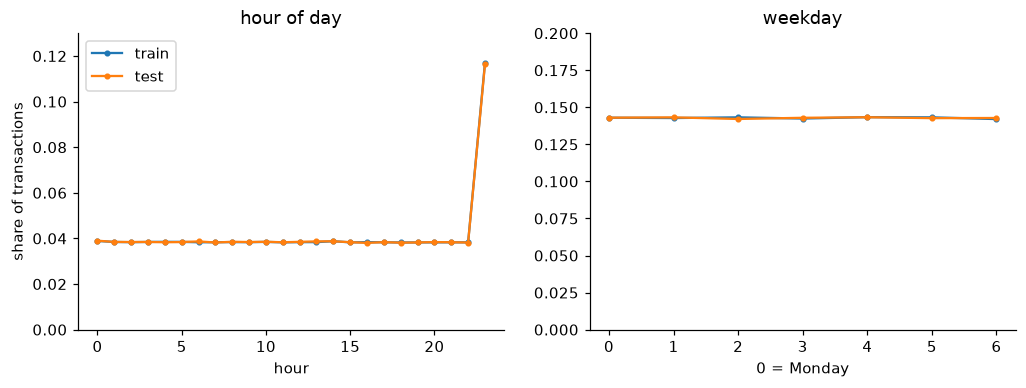

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for name, tx in [("train", tr_tx), ("test", te_tx)]:
    ts = tx["tranzaksiya_vaqti"]
    ts.dt.hour.value_counts(normalize=True).sort_index().plot(ax=axes[0], marker="o", ms=3, label=name)
    ts.dt.weekday.value_counts(normalize=True).sort_index().plot(ax=axes[1], marker="o", ms=3, label=name)
axes[0].set(title="hour of day", xlabel="hour", ylabel="share of transactions", ylim=(0, 0.13))
axes[1].set(title="weekday", xlabel="0 = Monday", ylim=(0, 0.2))
axes[0].legend()
save_fig(
    fig,
    "F00a_hour_weekday",
    "Hours 0-22 and all weekdays are flat (about 3.8% and 14.3% each); hour 23 alone holds 11.7% of transactions. No daytime pattern exists, so the timezone cannot be inferred and does not matter.",
    "No hour-of-day or weekday features; measure time relative to the alert date instead.",
)

Hours 0 to 22 and all seven weekdays sit at the uniform level (3.8% per hour, 14.3% per weekday). There is no daily or weekly rhythm to exploit, the timezone cannot be inferred and does not matter, and hour or weekday features would be noise. The one exception is hour 23 with three times the mass of any other hour. That is not a night-time habit: the next section shows it is a cluster of transactions sitting right before the alert date.

### Relative time: lookback window and the pre-alert cluster

Alerts fire on recent behaviour and analysts judge it against the customer's normal, so time only makes sense relative to the alert date. `lag_days` is alert date minus transaction day (0 = the alert day, 1 = the day before, negative = after the alert). Three questions: how long is the lookback, is anything recorded after the alert, and where does the hour-23 mass sit?

In [15]:
def add_rel_time(tx, sig):
    m = tx.merge(sig[["signal_id", "signal_sanasi"]], on="signal_id", how="left", validate="many_to_one")
    m["lag_days"] = (m["signal_sanasi"] - m["tranzaksiya_vaqti"].dt.normalize()).dt.days
    m["secs_before"] = (m["signal_sanasi"] - m["tranzaksiya_vaqti"]).dt.total_seconds()
    return m


def rel_time_stats(m):
    first_lag = m.groupby("signal_id")["lag_days"].max()
    last_hour = m["secs_before"].between(0, 3600)
    same_second = m.duplicated(["signal_id", "tranzaksiya_vaqti"])
    return pd.Series(
        {
            "lag_days_min": int(m["lag_days"].min()),
            "lag_days_max": int(m["lag_days"].max()),
            "lookback_days_median": float(first_lag.median()),
            "lookback_days_p05": float(first_lag.quantile(0.05)),
            "share_tx_after_alert_date": round(float((m["lag_days"] < 0).mean()), 5),
            "share_tx_on_alert_date": round(float((m["lag_days"] == 0).mean()), 5),
            "share_tx_day_before_alert": round(float((m["lag_days"] == 1).mean()), 4),
            "share_tx_last_hour_before_alert": round(float(last_hour.mean()), 4),
            "share_same_second_pairs_in_last_hour": round(float(same_second[last_hour].mean()), 4),
            "share_same_second_pairs_elsewhere": round(float(same_second[~last_hour].mean()), 5),
        }
    )


tr_m, te_m = add_rel_time(tr_tx, tr_sig), add_rel_time(te_tx, te_sig)
rel_time = pd.concat([rel_time_stats(tr_m).rename("train"), rel_time_stats(te_m).rename("test")], axis=1)
rel_time

,train,test
lag_days_min,0.00000,0.00000
lag_days_max,180.00000,180.00000
lookback_days_median,180.00000,180.00000
lookback_days_p05,170.00000,172.00000
share_tx_after_alert_date,0.00000,0.00000
share_tx_on_alert_date,0.00056,0.00048
share_tx_day_before_alert,0.08090,0.08000
share_tx_last_hour_before_alert,0.07900,0.07840
share_same_second_pairs_in_last_hour,0.16550,0.16130
share_same_second_pairs_elsewhere,0.00036,0.00012


The lookback is a fixed 180 days (median 180, 5th percentile 170) and nothing is recorded after the alert date in either set, so the question of whether to use post-alert transactions does not arise. Around 8% of all rows fall on the day before the alert, almost all of them within the last hour, and that hour also holds the same-second pairs (17% of its rows versus 0.04% elsewhere), so those are not data errors but part of a dense cluster.

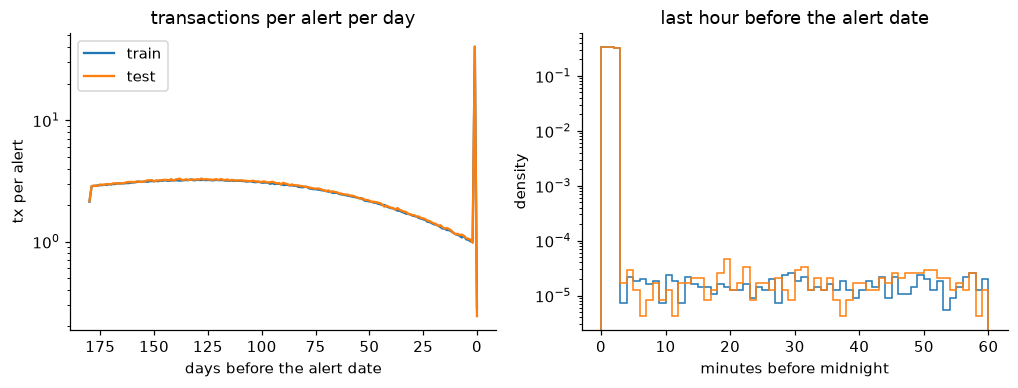

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for name, m, n in [("train", tr_m, len(tr_sig)), ("test", te_m, len(te_sig))]:
    (m["lag_days"].value_counts().sort_index() / n).plot(ax=axes[0], label=name)
    minutes = m.loc[m["secs_before"].between(0, 3600), "secs_before"] / 60
    axes[1].hist(minutes, bins=60, range=(0, 60), density=True, histtype="step", label=name)
axes[0].set(title="transactions per alert per day", xlabel="days before the alert date", ylabel="tx per alert", yscale="log")
axes[0].invert_xaxis()
axes[0].legend()
axes[1].set(title="last hour before the alert date", xlabel="minutes before midnight", ylabel="density", yscale="log")
save_fig(
    fig,
    "F00b_relative_time",
    "Every history covers a fixed 180-day lookback ending on the alert date, with nothing after it. About 8% of all transactions (median 31 per alert) sit in the last few minutes before the alert date starts; background activity is 1-3 per day and declines towards the alert. 152 alerts have no such cluster and 21 carry it late on the alert day itself.",
    "Treat the cluster (lag_days <= 1) as its own window; use 7/30/90/180-day windows for the background and recent-vs-baseline ratios.",
)

Left panel, read from left to right: background activity is a smooth hump. It rises from about 2 transactions per alert per day at 180 days out to a peak of about 3 around 120 days, then declines steadily to about 1 per day in the week before the alert, and then the last day jumps to about 40. Train and test lie on top of each other. The right panel zooms into that last hour: nearly everything sits in the last three minutes before midnight (median 1.5 minutes, 99% within 3), the rest of the hour is at the background level.

So an alert follows months of slowly falling activity and then a dense burst immediately before the alert date. The burst is the trigger; the preceding months are the customer's normal. Features should describe both and, above all, the burst relative to the background.

In [17]:
last_hour = tr_m[tr_m["secs_before"].between(0, 3600)]
cluster_size = last_hour.groupby("signal_id").size().reindex(tr_sig["signal_id"], fill_value=0)
late = tr_m[tr_m["secs_before"] < 0]
print("alerts without a last-hour transaction:", int((cluster_size == 0).sum()))
print("rows after the alert midnight, same calendar day:", len(late), "in", late["signal_id"].nunique(), "alerts")

pct = [0.01, 0.1, 0.5, 0.9, 0.99]
pd.DataFrame(
    {
        "minutes_before_midnight": (last_hour["secs_before"] / 60).describe(percentiles=pct),
        "cluster_size_per_alert": cluster_size.describe(percentiles=pct),
    }
).round(1)

alerts without a last-hour transaction: 152
rows after the alert midnight, same calendar day: 840 in 21 alerts


,minutes_before_midnight,cluster_size_per_alert
count,552279.0,14000.0
mean,1.5,39.4
std,1.3,35.9
min,0.0,0.0
1%,0.0,0.0
10%,0.3,6.0
50%,1.5,31.0
90%,2.6,83.0
99%,2.9,158.0
max,60.0,786.0


152 alerts (1%) have no burst at all and 21 carry it late on the alert day itself (their rows fall after midnight, still on the alert date). The burst window is therefore defined by `lag_days <= 1`, not by a clock time. Its size varies a lot between alerts (10th to 90th percentile: 6 to 83 transactions), which makes the burst the first place to look for behavioural differences once the audit is done.

### Amount index forensics

`miqdor_indeksi` is a standardized size indicator with an unknown transform. Whether it is a global z-score, a per-alert z-score (which would erase absolute size), signed by direction, or log-scaled decides which aggregates are meaningful.

In [18]:
amt = tr_tx["miqdor_indeksi"]
centered = (amt - amt.mean()).abs()
pd.Series(
    {
        "mean": amt.mean(),
        "sd": amt.std(),
        "min": amt.min(),
        "max": amt.max(),
        "share_negative": (amt < 0).mean(),
        "skew": amt.skew(),
        "excess_kurtosis": amt.kurt(),
        "within_1sd": (centered < amt.std()).mean(),
        "within_2sd": (centered < 2 * amt.std()).mean(),
        "within_3sd": (centered < 3 * amt.std()).mean(),
    }
).round(4)

mean              -0.1334
sd                 0.9811
min               -2.9123
max                6.6917
share_negative     0.6032
skew               0.6328
excess_kurtosis    0.9806
within_1sd         0.7116
within_2sd         0.9515
within_3sd         0.9925
dtype: float64

In [19]:
qs = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
pd.DataFrame({"train": amt.quantile(qs), "test": te_tx["miqdor_indeksi"].quantile(qs)}).round(3).T

,0.001,0.010,0.050,0.250,0.500,0.750,0.950,0.990,0.999
train,-2.884,-2.118,-1.542,-0.799,-0.244,0.430,1.641,2.639,3.947
test,-2.886,-2.119,-1.541,-0.791,-0.233,0.446,1.663,2.670,3.972


Mean −0.13, sd 0.98 and 71 / 95 / 99% of values within 1 / 2 / 3 sd: this is essentially a Gaussian with a mild right tail (skew 0.63) and a hard floor at −2.91. Train and test quantiles agree to two decimals, so the amount scale is the same in both sets.

In [20]:
per_sig = tr_tx.groupby("signal_id")["miqdor_indeksi"].agg(["mean", "std", "count"])
per_sig.loc[per_sig["count"] >= 10, ["mean", "std"]].describe().round(3)

,mean,std
count,13834.000,13834.000
mean,-0.062,0.866
std,0.492,0.207
min,-1.739,0.287
25%,-0.399,0.713
50%,-0.084,0.851
75%,0.253,0.997
max,1.844,1.917


Per-alert means spread with sd 0.49 and per-alert sds range from 0.3 to 1.9, so the index is not standardized within each alert. Absolute size differences between alerts survive and per-alert sums and means are meaningful.

In [21]:
tr_tx.groupby(CAT_COLS)["miqdor_indeksi"].agg(["count", "mean", "std", "median", "min", "max"]).round(3)

count   mean    std  median    min    max
kirim_chiqim tranzaksiya_turi                                             
chiqim       bank_otkazmasi     709255  0.318  1.155   0.269 -2.839  6.692
             karta              875947 -0.076  0.841  -0.122 -2.269  4.183
             naqd               108125  0.785  0.868   0.751 -1.321  4.863
             xalqaro              7456  2.169  1.151   2.066 -0.578  6.430
kirim        bank_otkazmasi    2045432  0.077  1.116   0.040 -2.912  6.692
             karta             2882850 -0.537  0.658  -0.574 -2.227  4.183
             naqd               334221  0.452  0.756   0.397 -1.257  4.563
             xalqaro             24377  1.934  1.043   1.796 -0.355  6.430

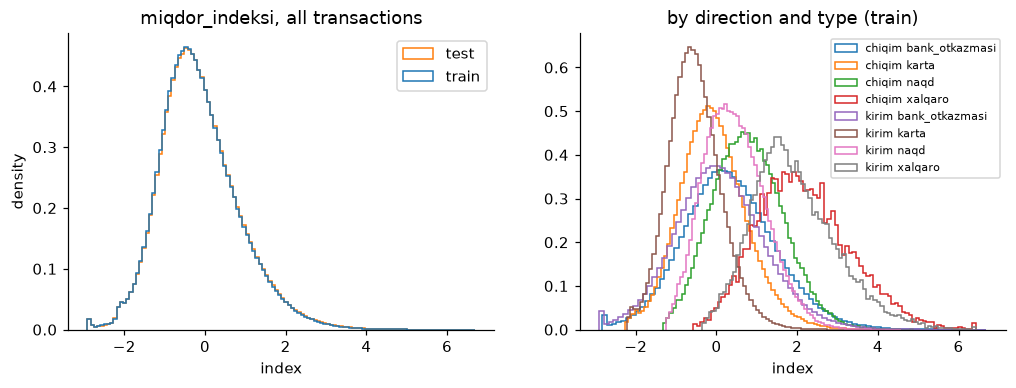

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([amt, te_tx["miqdor_indeksi"]], bins=120, density=True, histtype="step", label=["train", "test"])
axes[0].set(title="miqdor_indeksi, all transactions", xlabel="index", ylabel="density")
axes[0].legend()
for (direction, tx_type), s in tr_tx.groupby(CAT_COLS)["miqdor_indeksi"]:
    axes[1].hist(s, bins=80, density=True, histtype="step", label=f"{direction} {tx_type}")
axes[1].set(title="by direction and type (train)", xlabel="index")
axes[1].legend(fontsize=7)
save_fig(
    fig,
    "F00c_amount_index",
    "The index is one common scale for all transactions (not standardized per alert): near-normal with a right tail, a hard floor near -2.9, mean shifting by type (card lowest, international highest) and outgoing above incoming. Only four exact values repeat, and each is the maximum of one transaction type, so amounts are capped per type; the 120 alerts that hit a cap escalate at 13% vs 17% overall, within noise.",
    "Use the index as is (plus exp for money-like sums); build shares and counts above thresholds by type and direction; try a hit-the-cap flag.",
)

Every direction × type cell is itself a bell curve on the same scale, only shifted: card is lowest, then bank transfer, cash, and international about two sd higher, with outgoing above incoming in every channel. The overall skew is just the mixture of these shifted normals. A near-normal index whose mean moves with the payment channel is what a z-scored log-amount looks like, so `exp(index)` behaves like money and its sums are meaningful, while the raw index is fine for thresholds and shares.

Because the distributions are Gaussian per channel, a value two sd above its channel mean is unusual in the same sense for a card payment and for a cash deposit. That motivates channel-relative amount features (how far an alert's cash or international transactions sit from the channel norm, how many exceed the channel's 95th percentile) rather than one global threshold, which would mostly flag international transfers.

In [23]:
value_counts = amt.value_counts()
repeated = value_counts[value_counts > 1]
rep_rows = tr_tx[tr_tx["miqdor_indeksi"].isin(repeated.index)]
has_rep = tr_sig["signal_id"].isin(rep_rows["signal_id"])
print("values repeated exactly:", len(repeated), "| rows:", int(repeated.sum()), "| rows in test:", int(te_tx["miqdor_indeksi"].isin(repeated.index).sum()))
print("alerts with a repeated amount:", int(has_rep.sum()), "| their escalation rate:", round(tr_sig.loc[has_rep, TARGET].mean(), 3))
pd.crosstab(rep_rows["miqdor_indeksi"], [rep_rows["kirim_chiqim"], rep_rows["tranzaksiya_turi"]])

values repeated exactly: 4 | rows: 145 | rows in test: 85
alerts with a repeated amount: 120 | their escalation rate: 0.133


kirim_chiqim             chiqim                             kirim              
tranzaksiya_turi bank_otkazmasi karta naqd xalqaro bank_otkazmasi karta xalqaro
miqdor_indeksi                                                                 
4.183498                      0   114    0       0              0     1       0
4.862791                      0     0    6       0              0     0       0
6.430390                      0     0    0       7              0     0       6
6.691657                      6     0    0       0              5     0       0

Only four values repeat exactly among seven million rows, and each one is the maximum of a single transaction type (compare with the max column above): amounts are capped per channel and the repeats are transactions hitting the cap. No round-amount heaping survived the transform. Hitting a cap is rare (120 alerts) and shows no excess escalation (13% vs 17% overall), so at most it becomes a small flag to test later.

### ID and row-order artifacts

Synthetic data sometimes leaks the label through the way IDs were assigned or files were written. Anything found here is reported as a data-quality observation, never used as a feature.

In [24]:
id_num = tr_sig["signal_id"].str.slice(3).astype(int)
first_pos = tr_tx.reset_index().groupby("signal_id")["index"].first().reindex(tr_sig["signal_id"]).to_numpy()
alert_date = tr_sig["signal_sanasi"].astype("int64")

pd.Series(
    {
        "AUC id number": roc_auc_score(y, id_num),
        "AUC signal file row order": roc_auc_score(y, np.arange(len(y))),
        "AUC first position in the transaction file": roc_auc_score(y, first_pos),
        "AUC alert date": roc_auc_score(y, alert_date),
        "spearman(id, alert date)": id_num.corr(alert_date, method="spearman"),
    }
).round(4)

AUC id number                                 0.4985
AUC signal file row order                     0.4985
AUC first position in the transaction file    0.5078
AUC alert date                                0.5076
spearman(id, alert date)                     -0.0009
dtype: float64

In [25]:
all_ids = pd.concat([tr_sig["signal_id"], te_sig["signal_id"]]).str.slice(3).astype(int).to_numpy()
is_test = np.r_[np.zeros(len(tr_sig)), np.ones(len(te_sig))]
pd.Series(is_test).groupby(pd.qcut(all_ids, 10, labels=False)).mean().round(3).rename("test share by id decile")

0    0.298
1    0.290
2    0.322
3    0.300
4    0.282
5    0.302
6    0.294
7    0.297
8    0.299
9    0.315
Name: test share by id decile, dtype: float64

Nothing leaks: the ID number, both file orders and the alert date all score 0.50 to 0.51 against the target, and the ID is unrelated to the date. IDs run from 1 to 20000 with a 30% test share in every decile, so the test set is a random 30% sample of alerts, not a later period. That is the split the validation scheme has to mirror.

### Shared histories across alerts

One customer can trigger several alerts. If two alerts share identical transaction rows they belong to the same customer, which would call for group-aware validation and prior-alert features.

In [26]:
tx_all = pd.concat([tr_tx, te_tx], ignore_index=True)
row_hash = pd.util.hash_pandas_object(tx_all[["tranzaksiya_vaqti", "kirim_chiqim", "tranzaksiya_turi", "miqdor_indeksi"]], index=False)
row_alert = pd.DataFrame({"row_hash": row_hash.to_numpy(), "signal_id": tx_all["signal_id"].to_numpy()}).drop_duplicates()
shared = row_alert[row_alert.duplicated("row_hash", keep=False)]
del tx_all, row_hash

pd.Series(
    {
        "transaction rows, train + test": len(row_alert),
        "distinct rows": row_alert["row_hash"].nunique(),
        "rows under more than one alert": shared["row_hash"].nunique(),
        "alerts involved": shared["signal_id"].nunique(),
    }
)

transaction rows, train + test    10015238
distinct rows                     10015238
rows under more than one alert           0
alerts involved                          0
dtype: int64

Not a single row appears under two alerts, in train, in test or across them. Every alert is an independent history, so there are no pseudo-customers to group folds by and no prior-alert history to exploit. Plain stratified K-fold is safe.

### Dataset overview table and exports

The overview table, the schema and the figure findings go to the EDA website as its dataset section.

In [27]:
overview = pd.concat([overview, rel_time])
overview.loc["escalation_rate"] = [round(tr_sig[TARGET].mean(), 4), None]
overview.to_csv(ART_DIR / "F00_dataset_overview.csv")
schema.to_csv(ART_DIR / "F00_schema.csv", index=False)
(ART_DIR / "insights.json").write_text(json.dumps(INSIGHTS, indent=2, ensure_ascii=False))
overview

,train,test
signals,14000,6000
duplicate_signal_ids,0,0
distinct_alert_dates,730,728
signal_date_min,2025-01-01,2025-01-01
signal_date_max,2026-12-31,2026-12-31
tx_rows,6987663,3027575
exact_duplicate_tx_rows,0,0
same_second_tx_pairs,93749,38650
signals_without_tx,0,0
orphan_tx_signal_ids,0,0
